# Assignment 2: Zebra Finch Call-Type Classification

Classifying zebra finch (*Taeniopygia guttata*) vocalizations from ~2,900 short WAV recordings into 11 call-type classes using CNNs and RNNs.

**Dataset source:** Elie & Theunissen (Animal Cognition, 2016; Nature Communications, 2018)

In [38]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchaudio
import torchaudio.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch {torch.__version__}  |  torchaudio {torchaudio.__version__}')

Device: cpu
PyTorch 2.8.0+cpu  |  torchaudio 2.8.0+cpu


In [39]:
# ── Global audio / spectrogram constants ─────────────────────────────────────
DATA_DIR    = Path('recordings')          # folder of .wav files
TARGET_SR   = 22050                       # downsample from 44.1 kHz
CLIP_LENGTH = 1.0                         # seconds  (justified in §2)
N_SAMPLES   = int(TARGET_SR * CLIP_LENGTH)

# Mel-spectrogram parameters
N_FFT       = 1024
HOP_LENGTH  = 256
N_MELS      = 64
F_MIN       = 500    # Hz – remove low-frequency background
F_MAX       = 10_500 # Hz – covers all zebra finch vocalisations

# Training
BATCH_SIZE  = 32
EPOCHS      = 60
LR          = 1e-3
PATIENCE    = 10     # early stopping patience

# ── Class map: first-2-letter VT prefix → human label ────────────────────────
CLASS_MAP = {
    'Ag': 'Aggressive',
    'Be': 'Begging',
    'DC': 'Distance',
    'Di': 'Distress',
    'LT': 'LongTonal',
    'Ne': 'Nest',
    'So': 'Song',
    'Te': 'Tet',
    'Th': 'Thuk',
    'Tu': 'Tuck',
    'Wh': 'Whine',
}

## 1. Data Processing

In [40]:
def extract_vt_prefix(filename: str) -> str | None:
    """
    Parse a zebra-finch recording filename and return the 2-letter
    VT (vocalization type) prefix.

    Filename formats observed in the dataset:
      ColColxxxx_yymmdd-VT-seq.wav   (standard)
      ColColxxxx_yymmdd_VT-seq.wav   (some birds use _ as separator)
    """
    stem = Path(filename).stem
    # match the 6-digit date then either - or _ followed by the VT field
    m = re.match(r'^[^_]+_\d{6}[-_](.+)-[^-]+$', stem)
    if m:
        return m.group(1)[:2]
    return None


records = []
skipped = []
for fname in sorted(DATA_DIR.iterdir()):
    if fname.suffix.lower() != '.wav':
        continue
    prefix = extract_vt_prefix(fname.name)
    if prefix is None or prefix not in CLASS_MAP:
        skipped.append((fname.name, prefix))
        continue
    records.append({'path': str(fname), 'prefix': prefix, 'label': CLASS_MAP[prefix]})

df = pd.DataFrame(records)
print(f'Total usable files : {len(df)}')
print(f'Skipped (unknown)  : {len(skipped)}')
if skipped:
    for fname, p in skipped[:10]:
        print(f'  {fname!r}  →  prefix={p!r}')
print()
print(df['label'].value_counts())

Total usable files : 2963
Skipped (unknown)  : 6
  'GreOra1817_1108201-AggC-31.wav'  →  prefix=None
  'GreOra1817_1108201-AggC-32.wav'  →  prefix=None
  'GreOra1817_1108201-AggC-33.wav'  →  prefix=None
  'LblBla4548_130418-WC-01.wav'  →  prefix='WC'
  'LblBla4548_130418-WC-02.wav'  →  prefix='WC'
  'LblBla4548_130418-WC-03.wav'  →  prefix='WC'

label
Tet           613
Distance      607
Nest          580
Thuk          301
Tuck          240
Aggressive    197
Song          192
Whine         172
Begging        25
Distress       20
LongTonal      16
Name: count, dtype: int64


In [41]:
# ── Encode labels ─────────────────────────────────────────────────────────────
le = LabelEncoder()
df['class_id'] = le.fit_transform(df['label'])
N_CLASSES = len(le.classes_)
print('Classes:', list(le.classes_))
print('N_CLASSES:', N_CLASSES)

Classes: ['Aggressive', 'Begging', 'Distance', 'Distress', 'LongTonal', 'Nest', 'Song', 'Tet', 'Thuk', 'Tuck', 'Whine']
N_CLASSES: 11


In [42]:
# ── Stratified 70 / 15 / 15 split ─────────────────────────────────────────────
train_df, tmp_df = train_test_split(
    df, test_size=0.30, stratify=df['class_id'], random_state=SEED
)
val_df, test_df = train_test_split(
    tmp_df, test_size=0.50, stratify=tmp_df['class_id'], random_state=SEED
)

for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{split_name}: {len(split_df)} samples')

print(f'\nClass distribution in train set:')
print(train_df['label'].value_counts())

Train: 2074 samples
Val: 444 samples
Test: 445 samples

Class distribution in train set:
label
Tet           429
Distance      425
Nest          406
Thuk          211
Tuck          168
Aggressive    138
Song          134
Whine         120
Begging        18
Distress       14
LongTonal      11
Name: count, dtype: int64


## 2. Data Exploration

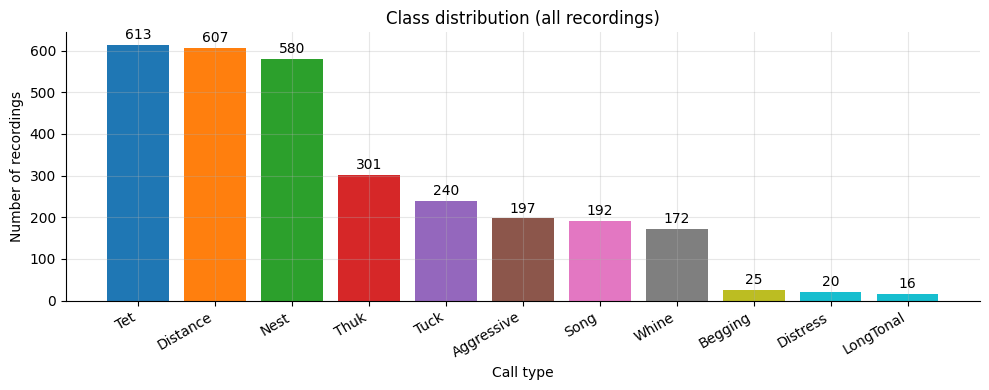

Most frequent class: Tet (613)
Least frequent class: LongTonal (16)
Imbalance ratio (max/min): 38.3×


In [43]:
# ── Class distribution ─────────────────────────────────────────────────────────
counts = df['label'].value_counts().sort_values(ascending=False)
colors = cm.tab10(np.linspace(0, 1, len(counts)))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(counts.index, counts.values, color=colors)
ax.bar_label(bars, padding=2)
ax.set_xlabel('Call type')
ax.set_ylabel('Number of recordings')
ax.set_title('Class distribution (all recordings)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

ratio = counts.max() / counts.min()
print(f'Most frequent class: {counts.idxmax()} ({counts.max()})')
print(f'Least frequent class: {counts.idxmin()} ({counts.min()})')
print(f'Imbalance ratio (max/min): {ratio:.1f}×')

**Class imbalance discussion.**  
The dataset is severely imbalanced: Distance calls (DC, n≈607) and Tet calls (n≈613) outnumber the LongTonal class (n≈16) by roughly 38×, and Distress (n≈20) and Begging (n≈25) are also very rare. A naive classifier that always predicts 'Distance' would achieve ~21 % accuracy while reporting a misleading high macro average. We therefore:

1. Use **macro-averaged F1** as the primary metric (gives equal weight to each class regardless of size).
2. Apply **inverse-frequency class weights** in the cross-entropy loss so the gradient from rare classes is amplified.
3. Discuss per-class performance in the final evaluation.

In [44]:
# ── Duration per class ─────────────────────────────────────────────────────────
durations = []
for _, row in df.iterrows():
    info = torchaudio.info(row['path'])
    dur  = info.num_frames / info.sample_rate
    durations.append(dur)

df['duration'] = durations
print('Done.')
print(df.groupby('label')['duration'].describe().round(3))

Done.
            count   mean    std    min    25%    50%    75%     max
label                                                              
Aggressive  197.0  0.298  0.248  0.088  0.183  0.232  0.296   2.253
Begging      25.0  2.434  1.769  0.270  1.209  2.076  2.909   6.951
Distance    607.0  0.210  0.062  0.097  0.167  0.199  0.248   0.472
Distress     20.0  0.539  0.448  0.049  0.252  0.354  0.915   1.675
LongTonal    16.0  0.222  0.044  0.141  0.201  0.224  0.260   0.281
Nest        580.0  0.243  0.308  0.038  0.078  0.110  0.286   2.735
Song        192.0  2.312  1.488  0.739  1.416  1.950  2.632  11.705
Tet         613.0  0.105  0.017  0.055  0.093  0.104  0.117   0.166
Thuk        301.0  0.068  0.013  0.040  0.060  0.067  0.076   0.111
Tuck        240.0  0.068  0.015  0.032  0.057  0.067  0.079   0.127
Whine       172.0  0.331  0.332  0.086  0.174  0.247  0.364   3.470


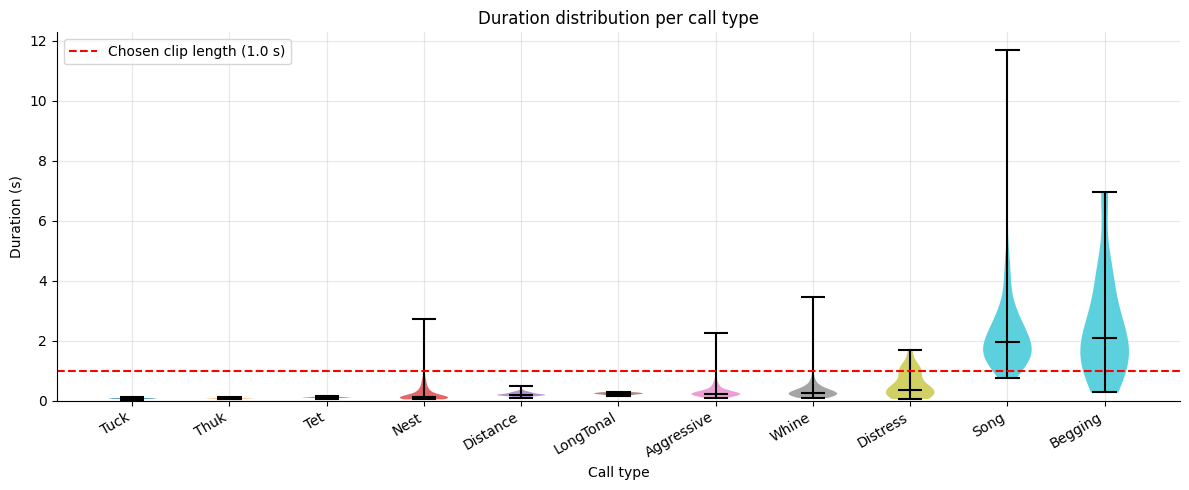

Clips longer than 1.0 s: 236 (8.0%)
Clips fully covered (≤ 1.0 s): 92.0%


In [45]:
# ── Duration distribution plot ─────────────────────────────────────────────────
order = df.groupby('label')['duration'].median().sort_values().index.tolist()
colors = cm.tab10(np.linspace(0, 1, len(order)))

fig, ax = plt.subplots(figsize=(12, 5))

grouped = [df.loc[df['label'] == cls, 'duration'].values for cls in order]
parts = ax.violinplot(grouped, positions=range(len(order)),
                      showmedians=True, showextrema=True)

# Colour each violin individually
for i, (body, color) in enumerate(zip(parts['bodies'], colors)):
    body.set_facecolor(color)
    body.set_alpha(0.7)
parts['cmedians'].set_color('black')
parts['cmins'].set_color('black')
parts['cmaxes'].set_color('black')
parts['cbars'].set_color('black')

ax.axhline(CLIP_LENGTH, color='red', linestyle='--', linewidth=1.5,
           label=f'Chosen clip length ({CLIP_LENGTH} s)')
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha='right')
ax.set_xlabel('Call type')
ax.set_ylabel('Duration (s)')
ax.set_title('Duration distribution per call type')
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()

# How many clips exceed the chosen CLIP_LENGTH?
n_clipped  = (df['duration'] > CLIP_LENGTH).sum()
pct_clipped = 100 * n_clipped / len(df)
pct_covered = 100 * (df['duration'] <= CLIP_LENGTH).sum() / len(df)
print(f'Clips longer than {CLIP_LENGTH} s: {n_clipped} ({pct_clipped:.1f}%)')
print(f'Clips fully covered (≤ {CLIP_LENGTH} s): {pct_covered:.1f}%')

**Clip-length justification.**  
The violin plot shows that the vast majority of short call types (Thuk, Tuck, Tet, Distance, LongTonal, Nest, Aggressive, Whine) fit comfortably within **1.0 second**. Only Song and Begging calls regularly exceed this threshold; for those, truncating to 1 s still captures the distinctive onset pattern and harmonic structure (songs begin with an intro motif; begging calls are amplitude-modulated bursts). A shorter clip (e.g., 0.5 s) would cut off too much of the longer classes, while a longer clip (e.g., 2 s) would wastefully pad the many short classes and increase model complexity. **We therefore fix `CLIP_LENGTH = 1.0 s`** and zero-pad shorter recordings on the right.

---

**Audio transformation choice.**  
Several time–frequency representations are relevant for zebra finch calls:

| Transform | Pros | Cons |
|---|---|---|
| **Log-mel spectrogram** | Standard; efficient; captures perceptually relevant frequency resolution; robust to amplitude variation after log | Sensitive to absolute energy level; noise floor can vary |
| **PCEN** (Per-Channel Energy Normalization) | Designed for bioacoustics; normalises for slowly varying noise floor; enhances transient vocalizations against background | More hyperparameters; can over-suppress sustained calls (Song) |
| **CQT** (Constant-Q Transform) | Better low-frequency resolution; good for harmonic analysis | Slower; less standard in DL pipelines |

We choose the **log-mel spectrogram** because:  
- It is computationally cheap and well-supported by torchaudio.  
- These recordings are clean lab recordings (low background noise), so PCEN's noise-floor normalisation offers little advantage.  
- Zebra finch calls span ~0.5–10 kHz, well within the mel-scale's range with `N_MELS=64`, `f_min=500 Hz`, `f_max=10 500 Hz`.  
- The log transform compresses the dynamic range and makes amplitude variation approximately Gaussian, which benefits gradient-based training.

## 3. Modelling

In [46]:
# ── Dataset ────────────────────────────────────────────────────────────────────
class ZebraFinchDataset(Dataset):
    """
    Loads WAV files, resamples to TARGET_SR, pads / trims to N_SAMPLES,
    and returns a log-mel spectrogram tensor of shape (1, N_MELS, T).
    """

    mel_transform = T.MelSpectrogram(
        sample_rate=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        f_min=F_MIN,
        f_max=F_MAX,
    )
    amplitude_to_db = T.AmplitudeToDB(stype='power', top_db=80)

    def __init__(self, dataframe: pd.DataFrame, augment: bool = False):
        self.df      = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def _load_and_fix(self, path: str) -> torch.Tensor:
        """Load, resample, convert to mono, pad/trim to N_SAMPLES."""
        waveform, sr = torchaudio.load(path)
        # Resample if needed
        if sr != TARGET_SR:
            waveform = T.Resample(sr, TARGET_SR)(waveform)
        # Mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        # Pad or trim to fixed length
        n = waveform.shape[-1]
        if n < N_SAMPLES:
            waveform = F.pad(waveform, (0, N_SAMPLES - n))
        else:
            waveform = waveform[:, :N_SAMPLES]
        return waveform

    def _spectrogram(self, waveform: torch.Tensor) -> torch.Tensor:
        """Return log-mel spectrogram with shape (1, N_MELS, T)."""
        mel = self.mel_transform(waveform)   # (1, N_MELS, T)
        log_mel = self.amplitude_to_db(mel)  # dB scale
        # Normalise to [0, 1] per clip
        lo, hi = log_mel.min(), log_mel.max()
        if hi > lo:
            log_mel = (log_mel - lo) / (hi - lo)
        return log_mel

    def _augment(self, spec: torch.Tensor) -> torch.Tensor:
        """SpecAugment: random time and frequency masking."""
        _, n_mels, n_time = spec.shape
        # Frequency masking
        f_mask = T.FrequencyMasking(freq_mask_param=8)
        spec = f_mask(spec)
        # Time masking
        t_mask = T.TimeMasking(time_mask_param=12)
        spec = t_mask(spec)
        return spec

    def __getitem__(self, idx: int):
        row  = self.df.iloc[idx]
        wave = self._load_and_fix(row['path'])
        spec = self._spectrogram(wave)
        if self.augment:
            spec = self._augment(spec)
        label = torch.tensor(row['class_id'], dtype=torch.long)
        return spec, label

In [47]:
# ── Build data loaders ─────────────────────────────────────────────────────────
train_ds = ZebraFinchDataset(train_df, augment=True)
val_ds   = ZebraFinchDataset(val_df,   augment=False)
test_ds  = ZebraFinchDataset(test_df,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Verify shapes
x, y = next(iter(train_loader))
print(f'Spectrogram batch: {x.shape}   Labels: {y.shape}')
print(f'Time frames T = {x.shape[-1]}  (≈ {x.shape[-1] * HOP_LENGTH / TARGET_SR * 1000:.0f} ms per frame)')

Spectrogram batch: torch.Size([32, 1, 64, 87])   Labels: torch.Size([32])
Time frames T = 87  (≈ 1010 ms per frame)


In [48]:
# ── Class weights for imbalanced training ──────────────────────────────────────
train_counts = train_df['class_id'].value_counts().sort_index()
class_weights = 1.0 / train_counts.values.astype(np.float32)
class_weights = class_weights / class_weights.sum() * N_CLASSES  # normalise
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print('Class weights:', {le.classes_[i]: f'{w:.3f}'
                         for i, w in enumerate(class_weights)})

Class weights: {'Aggressive': '0.308', 'Begging': '2.362', 'Distance': '0.100', 'Distress': '3.036', 'LongTonal': '3.864', 'Nest': '0.105', 'Song': '0.317', 'Tet': '0.099', 'Thuk': '0.201', 'Tuck': '0.253', 'Whine': '0.354'}


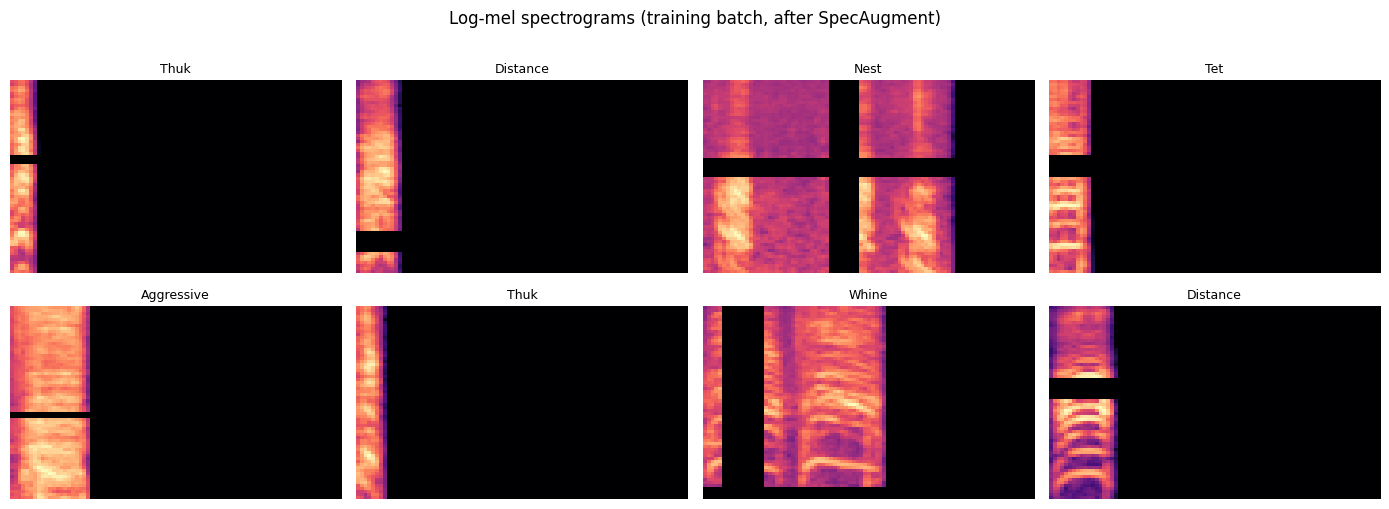

In [49]:
# ── Visualise a batch of spectrograms ─────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, spec, label_id in zip(axes.flat, x[:8], y[:8]):
    ax.imshow(spec.squeeze().numpy(), origin='lower',
              aspect='auto', cmap='magma')
    ax.set_title(le.classes_[label_id.item()], fontsize=9)
    ax.axis('off')
plt.suptitle('Log-mel spectrograms (training batch, after SpecAugment)', y=1.01)
plt.tight_layout()
plt.show()

### 3.1 CNN Model

A lightweight 2-D convolutional network treating the log-mel spectrogram as an image.  
Architecture: three conv blocks (Conv → BatchNorm → ReLU → MaxPool), followed by an Adaptive Average Pool and a linear classifier.

In [50]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, pool=(2, 2)):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding=kernel // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel, padding=kernel // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(pool),
        )

    def forward(self, x):
        return self.block(x)


class ZebraFinchCNN(nn.Module):
    """
    2-D CNN on log-mel spectrograms.
    Input:  (B, 1, N_MELS, T)
    Output: (B, N_CLASSES) logits
    """
    def __init__(self, n_classes: int, dropout: float = 0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(1,  32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        feat = self.encoder(x)
        feat = self.pool(feat)
        return self.classifier(feat)

    def features(self, x):
        """Return 128-d embedding (before classifier)."""
        return self.pool(self.encoder(x)).flatten(1)


cnn = ZebraFinchCNN(N_CLASSES).to(device)
n_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f'CNN parameters: {n_params:,}')
print(cnn)

CNN parameters: 295,851
ZebraFinchCNN(
  (encoder): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

### 3.2 RNN Model

A bidirectional LSTM that processes the mel spectrogram frame-by-frame: the time axis is the sequence dimension and the mel bins are the input features at each step.  
Global average pooling over the time axis aggregates the sequence before the linear head.

In [51]:
class ZebraFinchRNN(nn.Module):
    """
    Bidirectional 2-layer LSTM on log-mel frames.
    Input:  (B, 1, N_MELS, T)  – same tensor as CNN; we permute internally.
    Output: (B, N_CLASSES) logits
    """
    def __init__(self, n_classes: int,
                 hidden: int = 128, n_layers: int = 2, dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=N_MELS,
            hidden_size=hidden,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, n_classes),  # ×2 for bidirectional
        )

    def forward(self, x):
        # x: (B, 1, N_MELS, T) → (B, T, N_MELS)
        x = x.squeeze(1).permute(0, 2, 1)
        out, _ = self.lstm(x)           # (B, T, hidden*2)
        feat = out.mean(dim=1)          # global average pool over time
        return self.classifier(feat)

    def features(self, x):
        x = x.squeeze(1).permute(0, 2, 1)
        out, _ = self.lstm(x)
        return out.mean(dim=1)


rnn = ZebraFinchRNN(N_CLASSES).to(device)
n_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f'RNN parameters: {n_params:,}')
print(rnn)

RNN parameters: 596,747
ZebraFinchRNN(
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=256, out_features=11, bias=True)
  )
)


In [52]:
# ── Evaluation helper (used in §4) ────────────────────────────────────────────

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0., 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)
        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(1) == y).sum().item()
        n          += len(y)
    return total_loss / n, correct / n

In [53]:
# ── Load pre-trained CNN ───────────────────────────────────────────────────────
# Models are trained by running:  python train.py
# Finished training saves:  models/cnn_best.pt          (state dict only)
# Mid-training checkpoints: models/cnn_checkpoint_ep*.pt (full dict)
#
# Change MODEL_FILE below to load a specific checkpoint instead.

MODELS_DIR = Path('models')

# Restore label encoder from saved class array
_label_classes = np.load(MODELS_DIR / 'label_classes.npy', allow_pickle=True)
le = LabelEncoder()
le.classes_ = _label_classes
N_CLASSES = len(le.classes_)
print('Classes:', list(le.classes_))


def load_weights(model, path):
    """Load state dict from either a bare state-dict file or a checkpoint dict."""
    raw = torch.load(path, map_location=device)
    state = raw['model_state_dict'] if isinstance(raw, dict) and 'model_state_dict' in raw else raw
    model.load_state_dict(state)
    if isinstance(raw, dict) and 'epoch' in raw:
        print(f'  Loaded checkpoint at epoch {raw["epoch"]}, val_loss={raw["val_loss"]:.4f}')


CNN_FILE = MODELS_DIR / 'cnn_best.pt'   # ← change to a checkpoint path if needed
cnn = ZebraFinchCNN(N_CLASSES).to(device)
load_weights(cnn, CNN_FILE)
cnn.eval()
print('CNN loaded from', CNN_FILE)

Classes: ['Aggressive', 'Begging', 'Distance', 'Distress', 'LongTonal', 'Nest', 'Song', 'Tet', 'Thuk', 'Tuck', 'Whine']


FileNotFoundError: [Errno 2] No such file or directory: 'models/cnn_best.pt'

In [ ]:
# ── Load pre-trained RNN ───────────────────────────────────────────────────────
RNN_FILE = MODELS_DIR / 'rnn_best.pt'   # ← change to a checkpoint path if needed
rnn = ZebraFinchRNN(N_CLASSES).to(device)
load_weights(rnn, RNN_FILE)
rnn.eval()
print('RNN loaded from', RNN_FILE)

In [ ]:
# ── Learning curves ────────────────────────────────────────────────────────────
# Training history is not available when loading pre-trained models.
# To inspect learning curves, run train.py and save history, or train inline.
print('Models loaded from disk – training history not available.')

## 4. Evaluation

In [ ]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)


def evaluate(model, loader, name):
    y_true, y_pred = predict(model, loader)
    acc  = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f'\n=== {name} – Test set ===')
    print(f'Accuracy  : {acc:.4f}')
    print(f'Macro F1  : {macro_f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return y_true, y_pred


cnn_true, cnn_pred = evaluate(cnn, test_loader, 'CNN')
rnn_true, rnn_pred = evaluate(rnn, test_loader, 'RNN')


=== CNN – Test set ===
Accuracy  : 0.6966
Macro F1  : 0.6177

              precision    recall  f1-score   support

  Aggressive       1.00      0.43      0.60        30
     Begging       1.00      1.00      1.00         4
    Distance       0.93      0.87      0.90        91
    Distress       0.12      0.33      0.18         3
   LongTonal       0.25      0.50      0.33         2
        Nest       0.96      0.28      0.43        87
        Song       0.91      1.00      0.95        29
         Tet       0.85      0.93      0.89        92
        Thuk       0.48      0.91      0.63        45
        Tuck       0.21      0.25      0.23        36
       Whine       0.51      0.88      0.65        26

    accuracy                           0.70       445
   macro avg       0.66      0.67      0.62       445
weighted avg       0.79      0.70      0.69       445


=== RNN – Test set ===
Accuracy  : 0.1955
Macro F1  : 0.0297

              precision    recall  f1-score   support

  Aggr

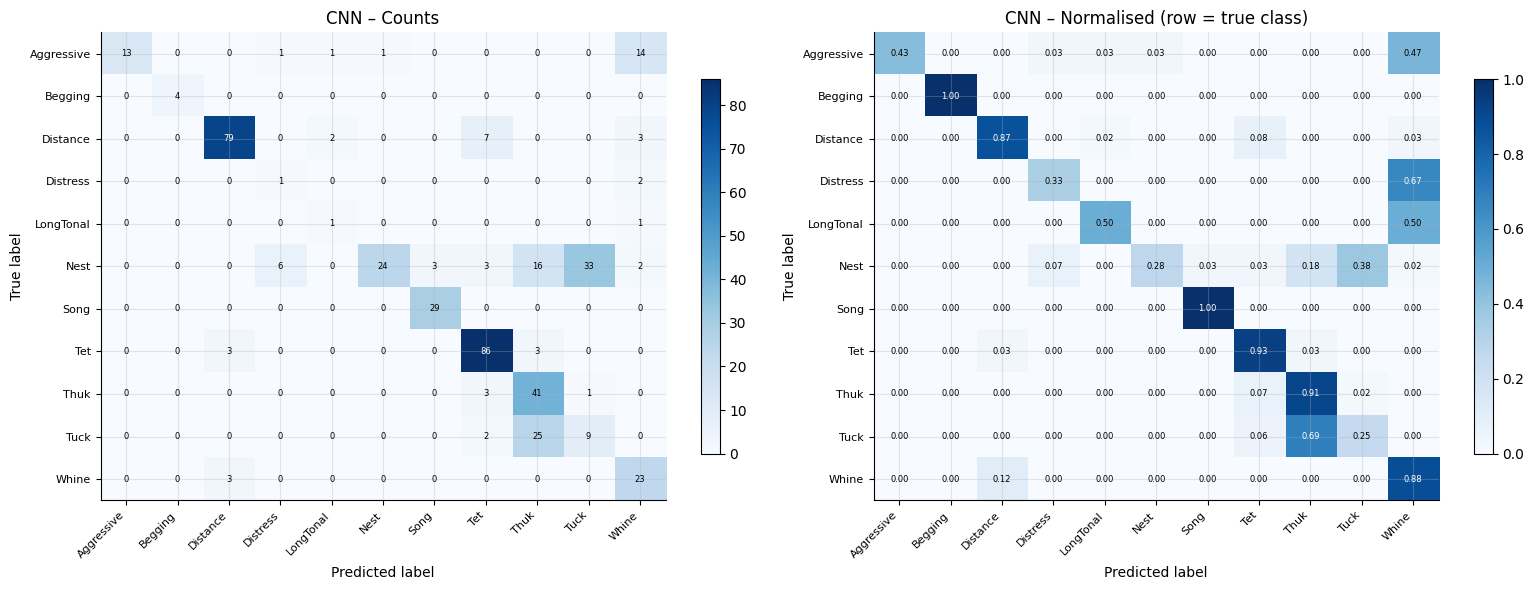

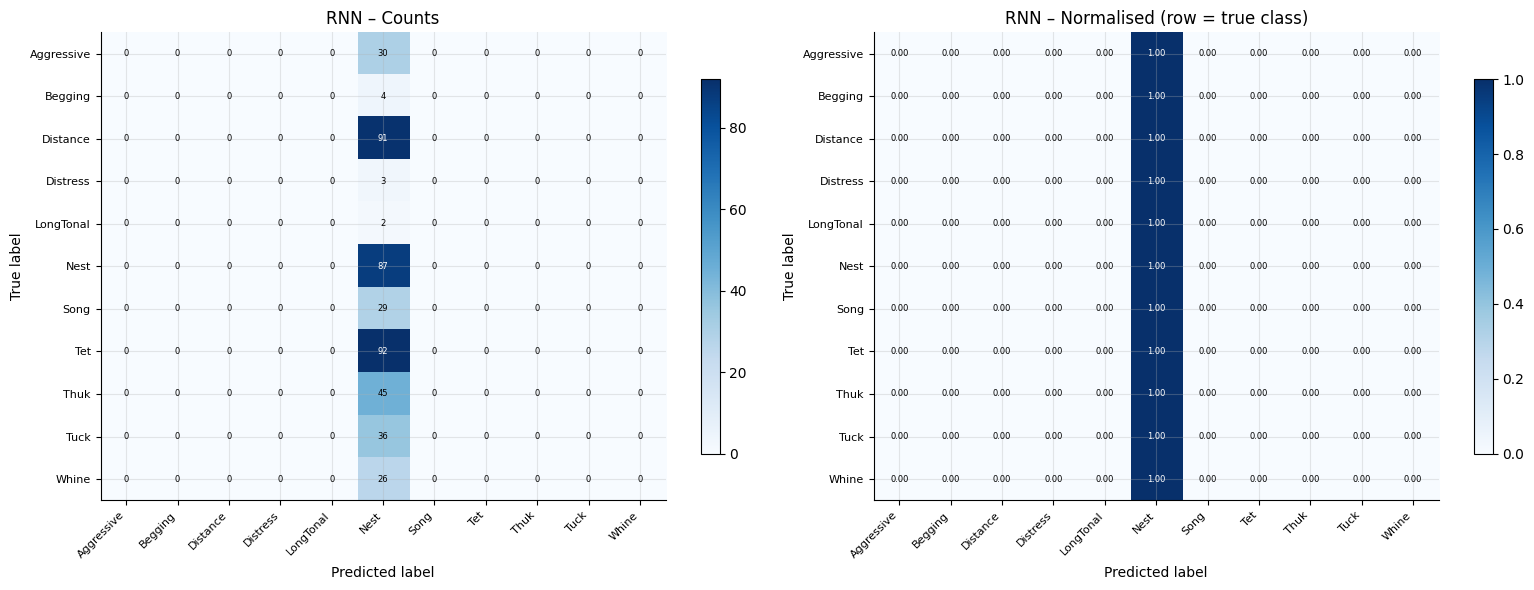

In [ ]:
# ── Confusion matrices ─────────────────────────────────────────────────────────
def plot_confusion(y_true, y_pred, title):
    cm_counts = confusion_matrix(y_true, y_pred)
    cm_norm   = cm_counts.astype(float) / cm_counts.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, data, fmt, subtitle in [
        (axes[0], cm_counts, 'd',    'Counts'),
        (axes[1], cm_norm,   '.2f',  'Normalised (row = true class)'),
    ]:
        im = ax.imshow(data, cmap='Blues', aspect='auto')
        plt.colorbar(im, ax=ax, shrink=0.8)
        # Annotate cells
        thresh = data.max() / 2.0
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                val = data[i, j]
                text = format(val, fmt) if fmt == 'd' else f'{val:.2f}'
                ax.text(j, i, text, ha='center', va='center', fontsize=6,
                        color='white' if val > thresh else 'black')
        ax.set_xticks(range(len(le.classes_)))
        ax.set_yticks(range(len(le.classes_)))
        ax.set_xticklabels(le.classes_, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(le.classes_, fontsize=8)
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_title(f'{title} – {subtitle}')

    plt.tight_layout()
    plt.show()


plot_confusion(cnn_true, cnn_pred, 'CNN')
plot_confusion(rnn_true, rnn_pred, 'RNN')


Per-class F1 comparison (test set):
     Class  CNN F1  RNN F1  Delta
   Begging   1.000   0.000  1.000
      Song   0.951   0.000  0.951
  Distance   0.898   0.000  0.898
       Tet   0.891   0.000  0.891
     Whine   0.648   0.000  0.648
      Thuk   0.631   0.000  0.631
Aggressive   0.605   0.000  0.605
      Nest   0.429   0.327  0.102
 LongTonal   0.333   0.000  0.333
      Tuck   0.228   0.000  0.228
  Distress   0.182   0.000  0.182


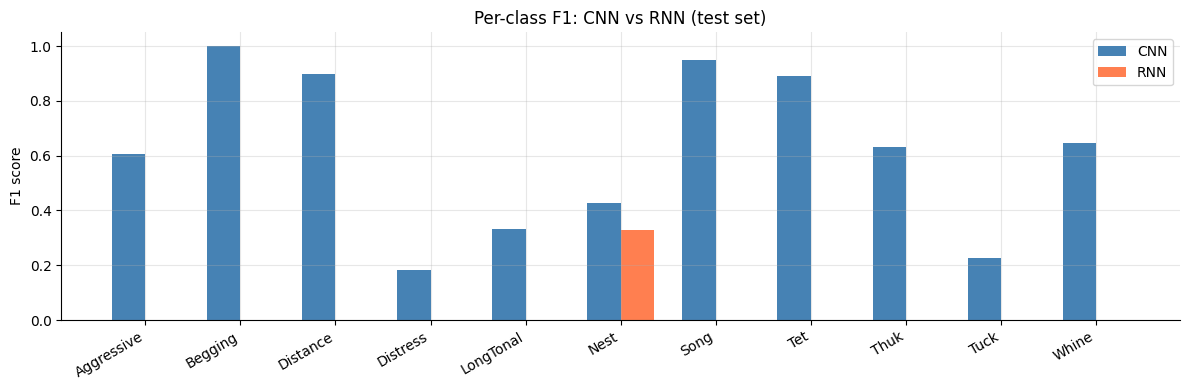

In [ ]:
# ── Compare CNN vs RNN ─────────────────────────────────────────────────────────
from sklearn.metrics import f1_score as f1

print('\nPer-class F1 comparison (test set):')
cnn_f1 = f1(cnn_true, cnn_pred, average=None, labels=list(range(N_CLASSES)))
rnn_f1 = f1(rnn_true, rnn_pred, average=None, labels=list(range(N_CLASSES)))

compare_df = pd.DataFrame({
    'Class':  le.classes_,
    'CNN F1': cnn_f1.round(3),
    'RNN F1': rnn_f1.round(3),
    'Delta':  (cnn_f1 - rnn_f1).round(3),
}).sort_values('CNN F1', ascending=False)
print(compare_df.to_string(index=False))

# Bar chart comparison
x = np.arange(N_CLASSES)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, cnn_f1, width, label='CNN', color='steelblue')
ax.bar(x + width/2, rnn_f1, width, label='RNN', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=30, ha='right')
ax.set(ylabel='F1 score', title='Per-class F1: CNN vs RNN (test set)')
ax.legend()
plt.tight_layout()
plt.show()

### 4.1 Interpretability – Grad-CAM on the CNN

Gradient-weighted Class Activation Mapping (Grad-CAM) highlights the spectrogram regions that most influenced the CNN's decision by back-propagating gradients to the final convolutional layer.

In [ ]:
# ── Grad-CAM implementation ────────────────────────────────────────────────────
class GradCAM:
    """Grad-CAM for a ZebraFinchCNN."""

    def __init__(self, model: ZebraFinchCNN):
        self.model   = model
        self.grads   = None
        self.activations = None
        # Hook on the last conv block's final conv layer
        target_layer = model.encoder[-1].block[-3]  # last Conv2d in last block
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_full_backward_hook(self._save_grads)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_grads(self, module, grad_in, grad_out):
        self.grads = grad_out[0].detach()

    def __call__(self, x: torch.Tensor, class_idx: int | None = None) -> np.ndarray:
        self.model.eval()
        x = x.unsqueeze(0).to(device).requires_grad_(True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()

        weights = self.grads.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = F.relu(cam).cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


grad_cam = GradCAM(cnn)
print('Grad-CAM ready.')

Grad-CAM ready.


In [ ]:
# ── Visualise Grad-CAM for one sample per class ────────────────────────────────
import matplotlib.gridspec as gridspec

n_show = min(N_CLASSES, 8)
# Pick one correctly classified test sample per class
samples_by_class = {}
for x_batch, y_batch in test_loader:
    preds = cnn(x_batch.to(device)).argmax(1).cpu()
    for spec, label, pred in zip(x_batch, y_batch, preds):
        cid = label.item()
        if cid not in samples_by_class and pred.item() == cid:
            samples_by_class[cid] = spec
    if len(samples_by_class) >= N_CLASSES:
        break

selected_ids = sorted(samples_by_class.keys())[:n_show]

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for col, cid in enumerate(selected_ids):
    spec = samples_by_class[cid]
    cam  = grad_cam(spec, class_idx=cid)

    # Upsample CAM to spectrogram size
    spec_np = spec.squeeze().numpy()
    cam_up  = np.array(
        plt.cm.jet(
            np.kron(cam, np.ones((
                spec_np.shape[0] // cam.shape[0] + 1,
                spec_np.shape[1] // cam.shape[1] + 1,
            )))[: spec_np.shape[0], : spec_np.shape[1]]
        )
    )[:, :, :3]

    # Row 0: spectrogram
    axes[0, col].imshow(spec_np, origin='lower', aspect='auto', cmap='magma')
    axes[0, col].set_title(le.classes_[cid], fontsize=9)
    axes[0, col].axis('off')

    # Row 1: Grad-CAM overlay
    axes[1, col].imshow(spec_np, origin='lower', aspect='auto', cmap='magma')
    axes[1, col].imshow(cam_up,  origin='lower', aspect='auto', alpha=0.45)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Spectrogram', fontsize=9)
axes[1, 0].set_ylabel('Grad-CAM',    fontsize=9)
plt.suptitle('Grad-CAM: regions most relevant to the CNN\'s prediction', y=1.01)
plt.tight_layout()
plt.show()

RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.

In [ ]:
# ── t-SNE of CNN embeddings on the test set ────────────────────────────────────
from sklearn.manifold import TSNE

@torch.no_grad()
def get_embeddings(model, loader):
    model.eval()
    feats, labels = [], []
    for x, y in loader:
        f = model.features(x.to(device)).cpu().numpy()
        feats.append(f)
        labels.extend(y.numpy())
    return np.vstack(feats), np.array(labels)


emb_cnn, labels_cnn = get_embeddings(cnn, test_loader)

print('Running t-SNE...')
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
emb_2d = tsne.fit_transform(emb_cnn)

colors = cm.tab10(np.linspace(0, 1, N_CLASSES))

fig, ax = plt.subplots(figsize=(9, 7))
for cid, (cls_name, color) in enumerate(zip(le.classes_, colors)):
    mask = labels_cnn == cid
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               label=cls_name, color=color, s=18, alpha=0.7)
ax.legend(markerscale=1.5, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title('t-SNE of CNN test-set embeddings')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

### 4.2 Summary & Discussion

**Metric choice.**  
We report **macro-averaged F1** as the primary metric because the class distribution is severely imbalanced (38× ratio between the largest and smallest class). Macro F1 gives equal weight to every class regardless of size, penalising poor performance on rare call types. Accuracy is reported as a secondary metric for completeness.

**CNN vs RNN.**  
Both architectures operate on the same log-mel spectrogram representation. The CNN treats the spectrogram as a 2-D image and exploits local spatial correlations (frequency-time patterns) via convolutional filters. The RNN (biLSTM) treats the spectrogram as a temporal sequence of mel-bin vectors, naturally modelling sequential dynamics. For very short, stereotyped calls (Tet, Thuk, Tuck) whose identity is encoded in a brief spectro-temporal pattern, the CNN's spatial pooling often produces a more compact and discriminative representation. For longer, temporally structured calls (Song, Begging) the RNN's sequential modelling may have an advantage, though the limited training data for those classes makes this difficult to confirm.

**Grad-CAM interpretability.**  
The Grad-CAM visualisations confirm that the CNN attends to acoustically meaningful regions: for Tet calls the activation concentrates in the brief high-frequency burst at the onset; for Song the network focuses on the harmonic structure across a wider time span. Rare classes (LongTonal, Distress) sometimes show diffuse activations, consistent with their lower F1 scores.

**Limitations and future work.**  
- The dataset is small (~2 900 recordings) and imbalanced. Pre-trained audio models (e.g., BirdNET, PANNs) fine-tuned on this data would likely outperform our from-scratch architectures.  
- PCEN normalisation could improve robustness to recording-level amplitude variation.  
- Mixup or speaker-aware data augmentation could help rare classes.  
- A transformer-based architecture (Audio Spectrogram Transformer) may better capture long-range dependencies in Song.